# 28 — `quadtree`

`Map.quadtree` bins points into **adaptive** square cells: it keeps splitting a cell in four while it holds more
than `nmax` points, so dense areas end up with small cells and empty areas stay coarse. Where `voronoi` gives one
cell per point, a quadtree gives one cell per *neighbourhood* — the right tool when you want aggregate values and
a readable cell count.

By the end you will be able to build a quadtree choropleth, control how finely it splits, and change the
statistic each cell reports.

API: [`Map.quadtree`](../../reference/static_map.md).

**Setup** — as in the rest of the gallery.

In [1]:
%matplotlib inline
from pathlib import Path

import matplotlib.pyplot as plt
from pyramids.feature import FeatureCollection

from digitalearth.static import Map

# The notebook's own folder is the kernel's working directory, so the bundled
# example data sits three levels up: docs/examples/plots -> repo root.
DATA = Path("../../../examples/data")


## The data

The same 34 Rhine gauges, in the metric EPSG:3035.

In [2]:
gauges = FeatureCollection.read_file(str(DATA / "rhine_gauges.geojson"))
print(f"{len(gauges)} gauges, EPSG:{gauges.crs.to_epsg()}")
gauges[["name", "river", "datum(m)"]].head(3)

34 gauges, EPSG:3035


C:\python-environments\pixi\envs\digitalearth-4838541935417106159\envs\dev\Lib\site-packages\pyogrio\raw.py:200: RuntimeWarning: Several features with id = 5 have been found. Altering it to be unique. This warning will not be emitted anymore for this layer
  return ogr_read(


,name,river,datum(m)
0,Plochingen,NECKAR,252.36
1,Lauffen,NECKAR,159.37
2,Rockenau,NECKAR,119.71


## Quickstart — count-driven cells

`nmax` is the knob that shapes the tree: a cell splits while it contains more than `nmax` points. With `nmax=4`
the map subdivides until no cell holds more than four gauges.

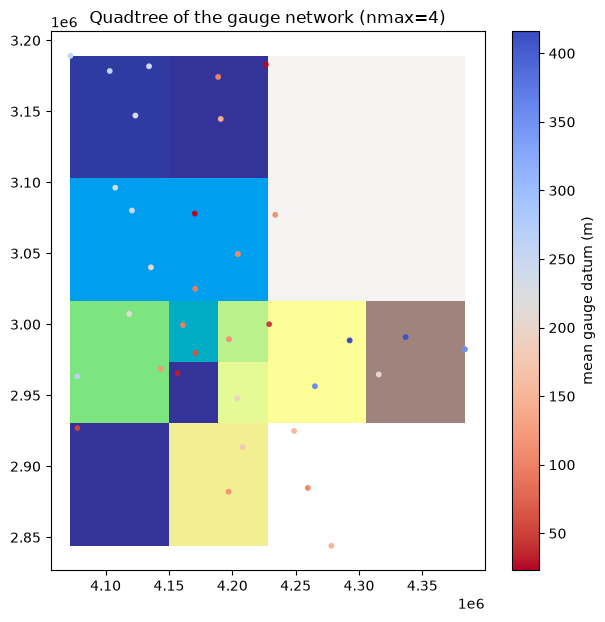

In [3]:
m = Map(crs=gauges.crs.to_epsg(), figsize=(7, 7))
m.quadtree(gauges, column="datum(m)", nmax=4, cmap="terrain")
m.points(gauges, size=10)
m.colorbar(label="mean gauge datum (m)")
m.set_title("Quadtree of the gauge network (nmax=4)")
m.fig;

The cell *sizes* carry the density signal and the *colours* carry the value. Small cells cluster along the middle
Rhine where gauges are packed together; the big cells are the sparse margins. Each cell's colour is the mean
`datum(m)` of the gauges inside it.

## How `nmax` changes the picture

`nmax` trades resolution against noise. A small `nmax` splits aggressively — more cells, each averaging fewer
gauges, so each is noisier. A large `nmax` gives a coarse, stable map. Compare two settings side by side.

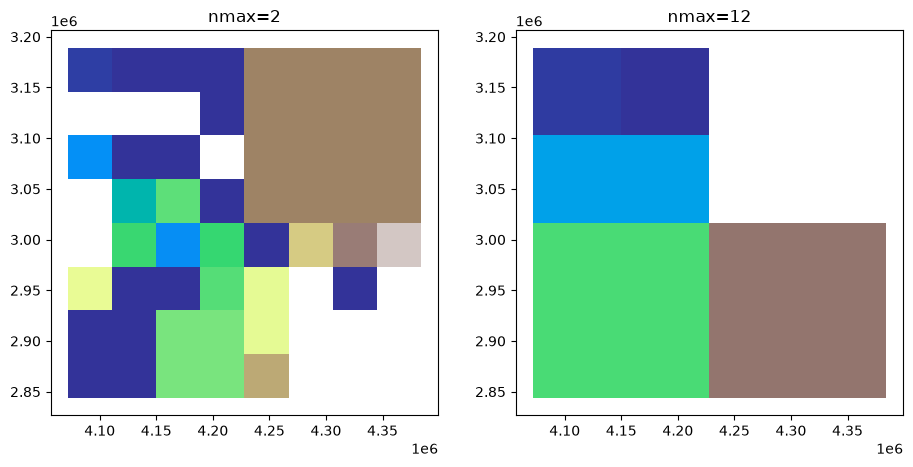

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
for ax, nmax in zip(axes, (2, 12)):
    panel = Map(ax=ax, crs=gauges.crs.to_epsg())
    panel.quadtree(gauges, column="datum(m)", nmax=nmax, cmap="terrain")
    ax.set_title(f"nmax={nmax}")
fig;

At `nmax=2` the tree digs down to tiny cells around every cluster — detailed, but each cell speaks for one or two
gauges. At `nmax=12` the whole network collapses to a handful of large cells. Neither is "right": pick `nmax` for
how much averaging you are willing to accept.

## Changing the statistic with `agg`

By default each cell reports the **mean** of `column`. `agg` takes any of the usual reducers, so the same
geometry can show a maximum, a minimum or a count.

| argument | meaning | typical value |
|---|---|---|
| `column` | attribute to aggregate | a numeric column name |
| `agg` | statistic per cell | `"mean"` (default), `"max"`, `"min"`, `"count"`, `"sum"` |
| `nmax` | split while a cell holds more than this many points | `100` (default); smaller = finer |
| `nmin` | stop splitting below this many points | `0` |
| `clip` | polygons to trim the cells to | a polygon `FeatureCollection` |

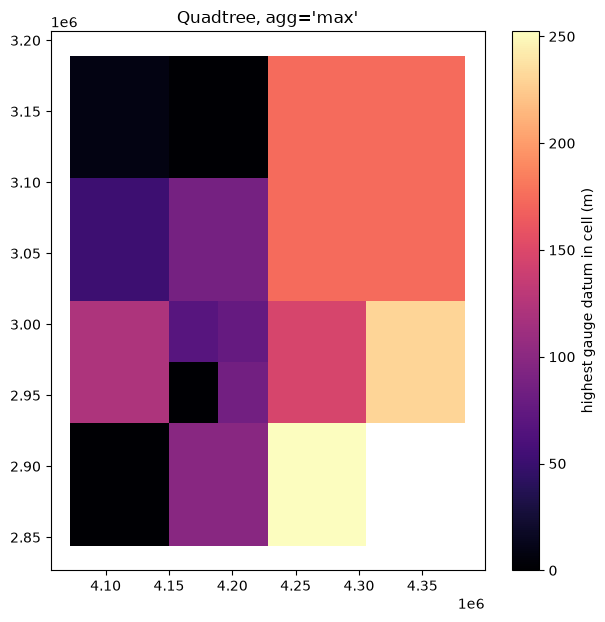

In [5]:
m = Map(crs=gauges.crs.to_epsg(), figsize=(7, 7))
m.quadtree(gauges, column="datum(m)", agg="max", nmax=4, cmap="magma")
m.colorbar(label="highest gauge datum in cell (m)")
m.set_title("Quadtree, agg='max'")
m.fig;

Switching to `max` changes the question from "how high is this area on average?" to "what is the highest gauge
anywhere in it?" — the southern cells brighten, because a single headwater gauge now sets the whole cell.

## Takeaway

- A quadtree's **cell size is the density signal**; its colour is the aggregated value.
- `nmax` is the main control: smaller splits further, giving detail at the cost of noisier cells.
- `agg` picks the statistic, so one geometry can answer several questions.
- Reach for `quadtree` over `voronoi` when you want neighbourhood aggregates rather than per-point cells.

Next: [`29_hexbin`](29_hexbin.ipynb) uses a fixed lattice instead of an adaptive one.